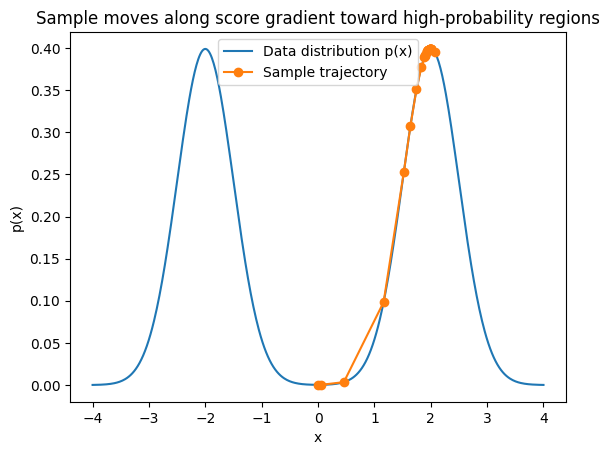

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define mixture of Gaussians
def p(x):
    return 0.5 * norm.pdf(x, -2, 0.5) + 0.5 * norm.pdf(x, 2, 0.5)

def score(x):
    # Numerical derivative of log p(x)
    eps = 1e-5
    return (np.log(p(x + eps)) - np.log(p(x - eps))) / (2 * eps)

# Start from pure noise
x = 0.0
trajectory = [x]

# Reverse diffusion steps
eta = 0.1   # step along score
sigma = 0.05  # stochasticity
for t in range(30):
    grad = score(x)
    x = x + eta * grad + sigma * np.random.randn()
    trajectory.append(x)

# Plot
xs = np.linspace(-4, 4, 500)
plt.plot(xs, p(xs), label="Data distribution p(x)")
plt.plot(trajectory, [p(x) for x in trajectory], 'o-', label="Sample trajectory")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Sample moves along score gradient toward high-probability regions")
plt.legend()
plt.show()


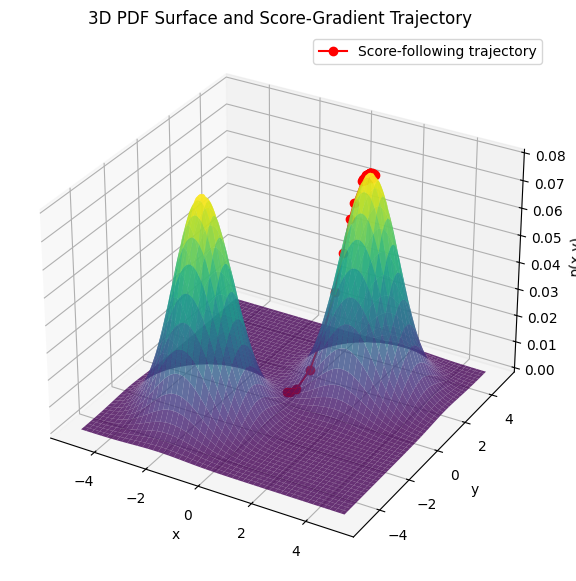

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define 2D Gaussian mixture distribution
mean1 = np.array([-2, -2])
mean2 = np.array([2, 2])
cov = np.eye(2)

rv1 = multivariate_normal(mean1, cov)
rv2 = multivariate_normal(mean2, cov)

def p(x, y):
    pos = np.dstack((x, y))
    return 0.5 * rv1.pdf(pos) + 0.5 * rv2.pdf(pos)

def score(x, y):
    eps = 1e-4
    # Numerical gradient of log p(x,y)
    dpdx = (np.log(p(x+eps, y)) - np.log(p(x-eps, y))) / (2*eps)
    dpdy = (np.log(p(x, y+eps)) - np.log(p(x, y-eps))) / (2*eps)
    return np.array([dpdx, dpdy])

# Grid for PDF surface
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = p(X, Y)

# Simulate trajectory along score (reverse diffusion analogy)
eta = 0.25
sigma = 0.05
point = np.array([0.0, 0.0])  # start from noise
trajectory = [point.copy()]

for t in range(50):
    grad = score(point[0], point[1])
    point = point + eta * grad + sigma * np.random.randn(2)
    trajectory.append(point.copy())

trajectory = np.array(trajectory)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

# Plot trajectory lifted onto PDF surface
Z_traj = p(trajectory[:,0], trajectory[:,1])
ax.plot(trajectory[:,0], trajectory[:,1], Z_traj, color='red', marker='o', label="Score-following trajectory")

ax.set_title("3D PDF Surface and Score-Gradient Trajectory")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("p(x,y)")
ax.legend()

plt.show()


In [19]:
import numpy as np
from scipy.stats import multivariate_normal
import plotly.graph_objects as go

# === Define 5-Mode 2D Gaussian Mixture ===
rand = np.random.randint

means = [
    np.array([rand(-50, 50), rand(-50, 50)]) for _ in range(5)
]
covs = [np.eye(2) * 100,  # Broad for the first mode
        np.eye(2) * 50,   # Narrow for the second mode
        np.eye(2) * 30,   # Even narrower
        np.eye(2) * 75,   # Medium for the fourth mode
        np.eye(2) * 120]  # Widest for the fifth mode

components = [multivariate_normal(mean, cov) for mean, cov in zip(means, covs)]

def p(x, y):
    pos = np.dstack((x, y))
    return sum(c.pdf(pos) for c in components) / len(components)

def score(x, y):
    eps = 1e-4
    dpdx = (np.log(p(x+eps, y)) - np.log(p(x-eps, y))) / (2 * eps)
    dpdy = (np.log(p(x, y+eps)) - np.log(p(x, y-eps))) / (2 * eps)
    return np.array([dpdx, dpdy])

# === Grid for surface ===
x = np.linspace(-60, 60, 150)
y = np.linspace(-60, 60, 150)
X, Y = np.meshgrid(x, y)
Z = p(X, Y)

# === Function to generate stochastic trajectory ===
def generate_trajectory(steps=120, eta=0.35, sigma=0.25):
    point = np.random.uniform(-10, 10, size=2)  # random start
    traj = [point.copy()]
    for _ in range(steps):
        grad = score(point[0], point[1])
        point = point + eta * grad + sigma * np.random.randn(2)
        traj.append(point.copy())
    traj = np.array(traj)
    Z_traj = p(traj[:,0], traj[:,1])
    return traj, Z_traj

# === Generate figure with Plotly ===
traj, Z_traj = generate_trajectory()

fig = go.Figure()

# PDF surface
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='Viridis',
    opacity=0.85,
    showscale=False
))

# Trajectory line
fig.add_trace(go.Scatter3d(
    x=traj[:,0],
    y=traj[:,1],
    z=Z_traj,
    mode="lines+markers",
    line=dict(color="red", width=5),
    marker=dict(size=5, color="red"),
    name="Reverse Diffusion Trajectory"
))

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="p(x,y)",
        camera=dict(eye=dict(x=1.7, y=1.7, z=1.2))
    ),
    title="Randomized Reverse Diffusion Trajectory"
)

fig.show()
